In [5]:
import pandas as pd

file_path = "../data/online+retail/Online Retail.xlsx"
df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 541909
Columns: 8


In [6]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(5268)

In [10]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 536641


In [11]:
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled transactions:", cancelled.sum())

Cancelled transactions: 9251


In [12]:
(df["Quantity"] < 0).sum()

np.int64(10587)

In [13]:
(df["UnitPrice"] <= 0).sum()


np.int64(2512)

In [14]:
df[df["UnitPrice"] <= 0][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]
].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN
1988,536550,85044,NaN,1,0.0,NaN
2024,536552,20950,NaN,1,0.0,NaN
2025,536553,37461,NaN,3,0.0,NaN
2026,536554,84670,NaN,23,0.0,NaN
2406,536589,21777,NaN,-10,0.0,NaN


In [15]:
df = df[df["UnitPrice"] > 0]

print("Rows after removing invalid prices:", df.shape[0])

Rows after removing invalid prices: 534129


In [16]:
(df["Quantity"] < 0).sum()

np.int64(9251)

In [17]:
df = df[df["Quantity"] > 0]

print("Rows after removing cancelled/returned transactions:", df.shape[0])

Rows after removing cancelled/returned transactions: 524878


In [18]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [19]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 10642110.804000001


In [20]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

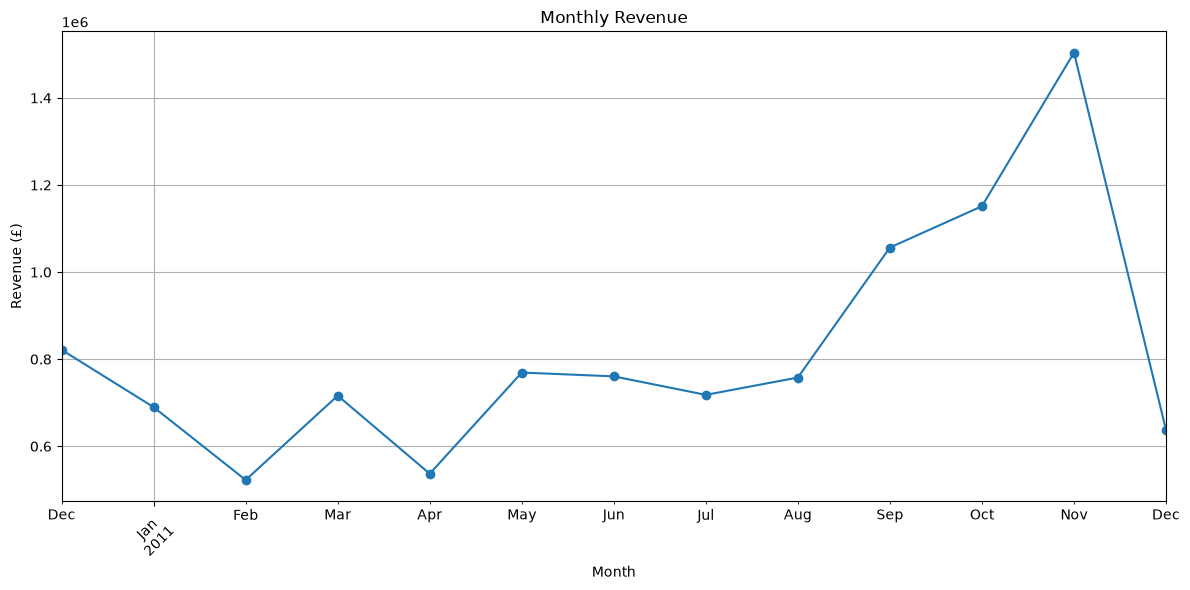

In [21]:
import matplotlib.pyplot as plt

monthly_revenue.plot(
    kind="line",
    marker="o",
    figsize=(12, 6)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

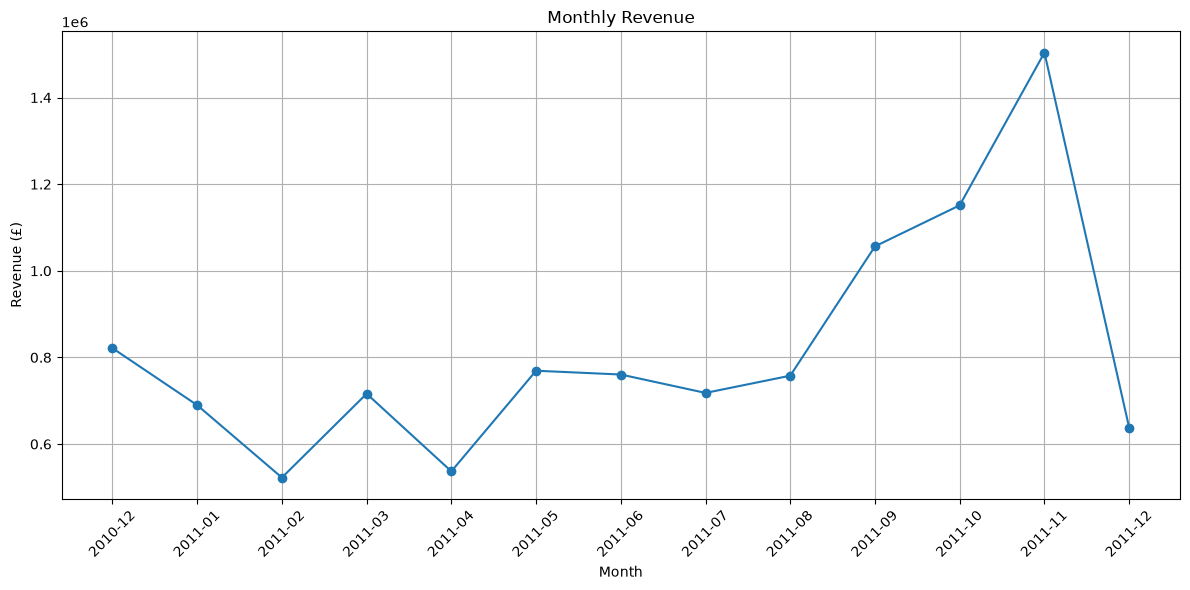

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig("../images/monthly_revenue.png", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python environment is ready!")
print("Pandas version:", pd.__version__)

Matplotlib is building the font cache; this may take a moment.


Python environment is ready!
Pandas version: 3.0.6


In [24]:

excluded = ["DOTCOM POSTAGE", "POSTAGE", "Manual"]

top_products = (
    df[~df["Description"].isin(excluded)]
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
CHILLI LIGHTS                          54096.36
Name: Revenue, dtype: float64

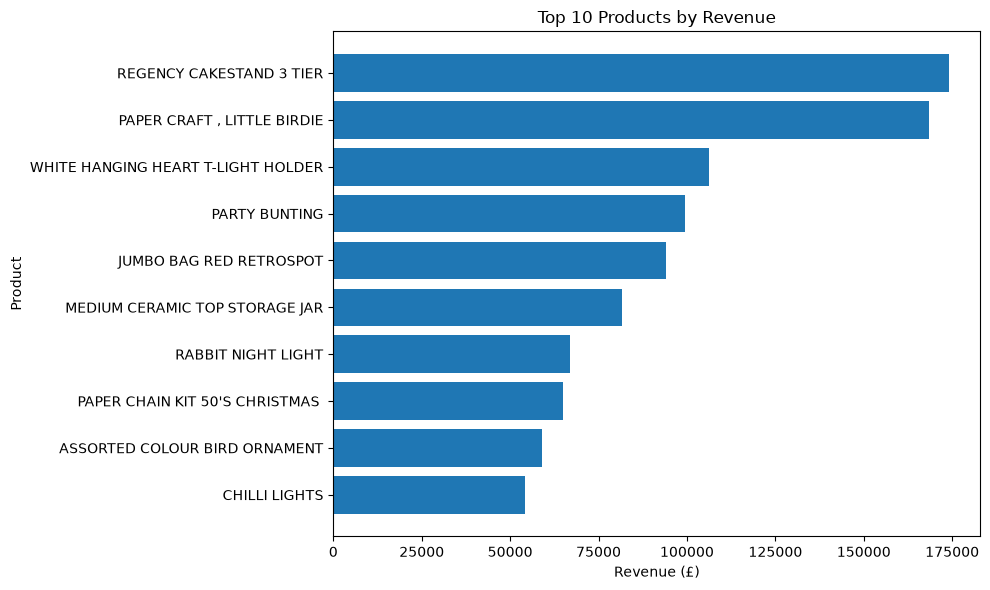

In [25]:
import matplotlib.pyplot as plt

top_products_sorted = top_products.sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_sorted.index,
    top_products_sorted.values
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "../images/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

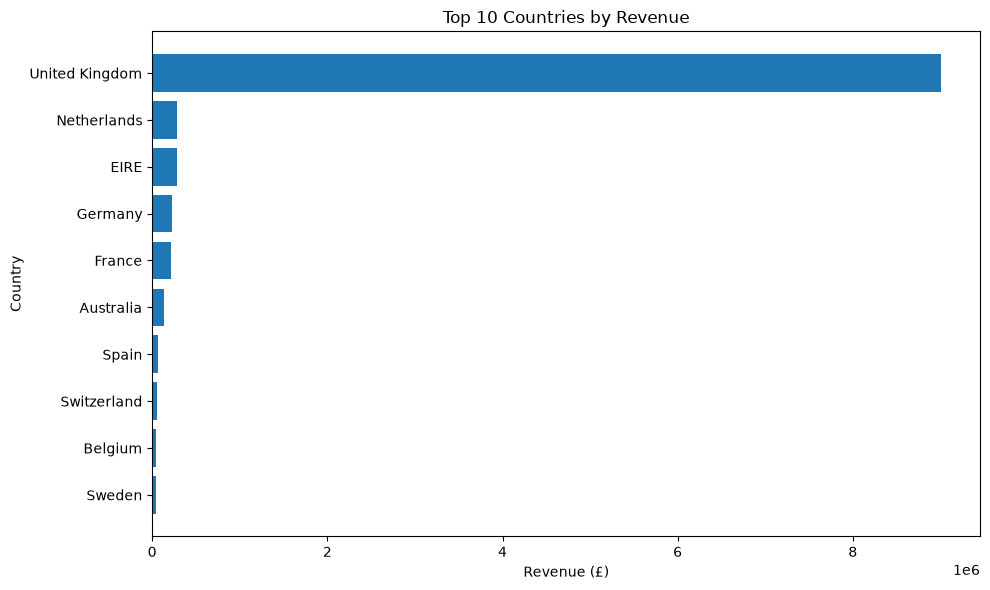

In [27]:
import matplotlib.pyplot as plt

top_countries = country_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries.index,
    top_countries.values
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    "../images/top_10_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
customer_revenue = (
    df[df["CustomerID"].notna()]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

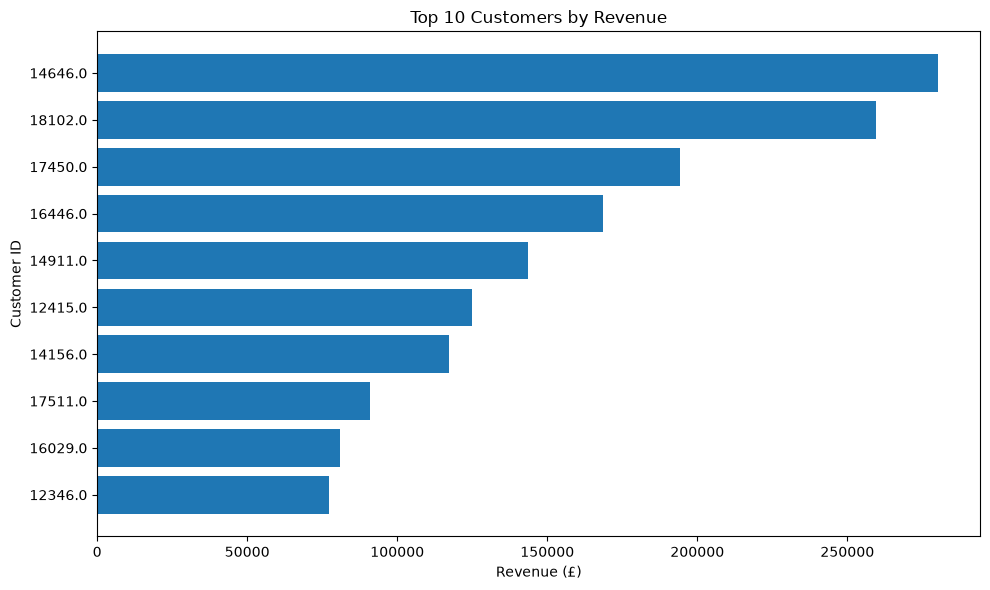

In [29]:
top_customers = customer_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers.index.astype(str),
    top_customers.values
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    "../images/top_10_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

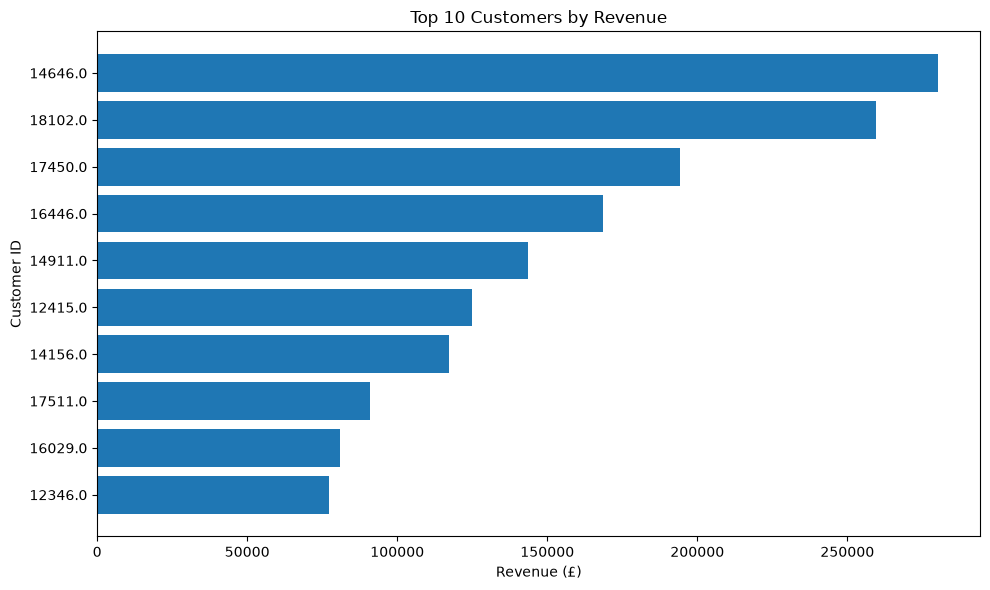

In [30]:
top_customers = customer_revenue.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers.index.astype(str),
    top_customers.values
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")

plt.tight_layout()

plt.savefig(
    "../images/top_10_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
# Tổng số khách hàng
total_customers = df["CustomerID"].nunique()

# Doanh thu trung bình trên mỗi khách hàng
average_customer_revenue = customer_revenue.mean()

print("Total Customers:", total_customers)
print("Average Revenue per Customer: £", round(average_customer_revenue, 2))

Total Customers: 4338
Average Revenue per Customer: £ 2048.69


In [32]:
monthly_orders = (
    df.groupby("Month")["InvoiceNo"]
    .nunique()
)

monthly_orders

Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

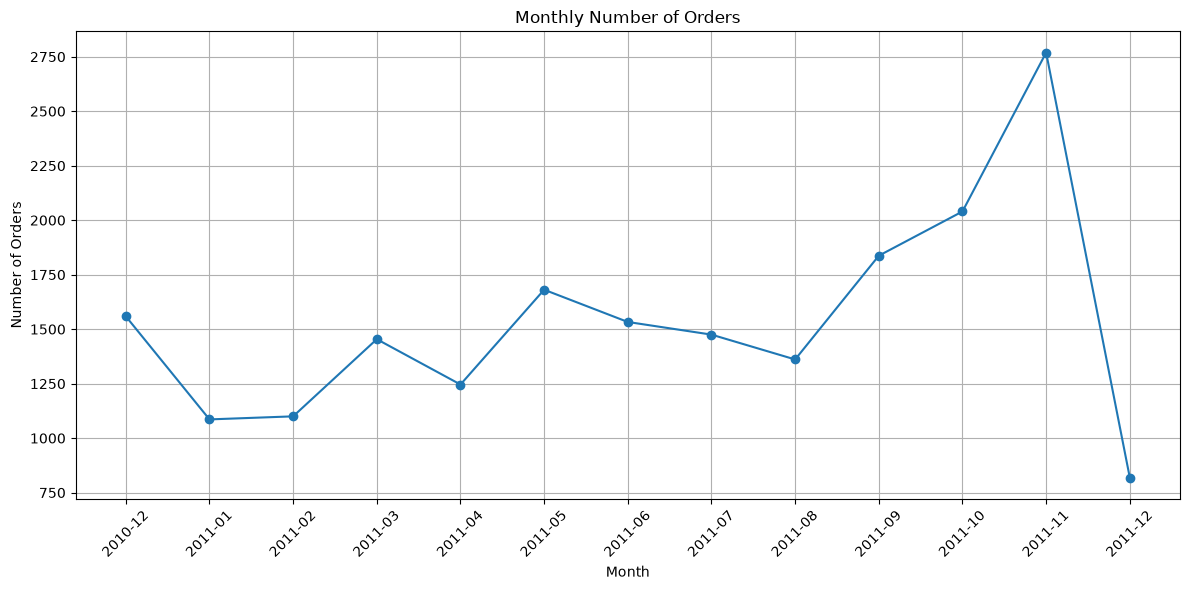

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../images/monthly_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
best_month = monthly_revenue.idxmax()
best_month_revenue = monthly_revenue.max()

print("Best Revenue Month:", best_month)
print("Revenue:", round(best_month_revenue, 2))

Best Revenue Month: 2011-11
Revenue: 1503866.78


In [35]:
best_product = top_products.idxmax()
best_product_revenue = top_products.max()

print("Top Product:", best_product)
print("Revenue:", round(best_product_revenue, 2))

Top Product: REGENCY CAKESTAND 3 TIER
Revenue: 174156.54


In [36]:
best_country = country_revenue.idxmax()
best_country_revenue = country_revenue.max()

print("Top Country:", best_country)
print("Revenue:", round(best_country_revenue, 2))

Top Country: United Kingdom
Revenue: 9001744.09


## 📌 Key Business Insights

### 1. Monthly Revenue
November 2011 generated the highest monthly revenue at approximately £1.50 million.
This indicates strong sales performance during the period.

> Note: December 2011 contains data only up to December 9, so it should not be directly compared with a full month.

### 2. Top Product
The highest-revenue product was **REGENCY CAKESTAND 3 TIER**, generating approximately £174,156.54.

This product shows strong customer demand and makes a significant contribution to total revenue.

### 3. Top Country
The **United Kingdom** generated the highest revenue at approximately £9.00 million.

This shows that the UK was the main market in the dataset, while other countries contributed smaller amounts of revenue.

### 4. Customer Analysis
The dataset contains **4,338 identified customers** with CustomerID.

The average revenue per identified customer was approximately **£2,048.69**.

### 5. Business Implications
- Focus on high-performing products to maintain sales growth.
- Analyze customer purchasing behavior to identify valuable customers.
- Strengthen the UK market while exploring opportunities in other countries.
- Investigate seasonal sales patterns to support inventory and marketing decisions.